In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import geopandas as gpd

from utils import load_dataset, extract_shamsi_year, calculate_real_price, prepare_amenities_gdf, plot_amenities_scatter, plot_amenities_choropleth, test_business_deed_effect, test_amenity_effect_on_price

In [2]:
df = load_dataset('Divar.csv')
data = df.copy()
data.head()

c:\Users\Poori\Desktop\divar-estate-ml\src\preprocess_feutures\utils.py:16: DtypeWarning: Columns (11,27,29,53) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(path)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,...,NaN,4.0,6,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
data.iloc[:, :20].head()

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,rent_value,rent_to_single,rent_type,price_mode,price_value,credit_mode,credit_value,rent_credit_transform,transformable_price,transformable_credit,transformed_credit
0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,NaN,NaN,NaN,مقطوع,8.500000e+09,NaN,NaN,NaN,NaN,NaN,NaN
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,26000000.0,NaN,NaN,NaN,NaN,مقطوع,750000000.0,False,False,750000000.0,NaN
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,95000000.0,NaN,NaN,NaN,NaN,مقطوع,950000000.0,False,False,950000000.0,NaN
4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,NaN,NaN,NaN,مقطوع,5.750000e+09,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
data.iloc[:, :20].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   cat2_slug              1000000 non-null  object 
 1   cat3_slug              999999 non-null   object 
 2   city_slug              999998 non-null   object 
 3   neighborhood_slug      437139 non-null   object 
 4   created_at_month       1000000 non-null  object 
 5   user_type              288882 non-null   object 
 6   description            1000000 non-null  object 
 7   title                  999946 non-null   object 
 8   rent_mode              352994 non-null   object 
 9   rent_value             351322 non-null   float64
 10  rent_to_single         19 non-null       object 
 11  rent_type              103961 non-null   object 
 12  price_mode             573606 non-null   object 
 13  price_value            568346 non-null   float64
 14  credit_mode        

In [49]:
data['cat2_slug'].isnull().sum()

np.int64(0)

In [50]:
data['cat2_slug'].value_counts()

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

In [27]:
data[data['rent_mode'] == 'مجانی']['rent_value']

11        0.0
38        0.0
48        0.0
65        0.0
92        0.0
         ... 
999956    0.0
999960    0.0
999967    0.0
999979    0.0
999999    0.0
Name: rent_value, Length: 59241, dtype: float64

In [19]:
data['city_slug'].value_counts()[data['city_slug'].value_counts() > 100]

city_slug
tehran       190904
mashhad       69032
karaj         49367
shiraz        37141
isfahan       36953
              ...  
ramshir         111
marzikola       109
bisotun         108
deylaman        106
bafq            101
Name: count, Length: 334, dtype: int64

In [4]:
data['cat2_slug'].value_counts()

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64

<Axes: >

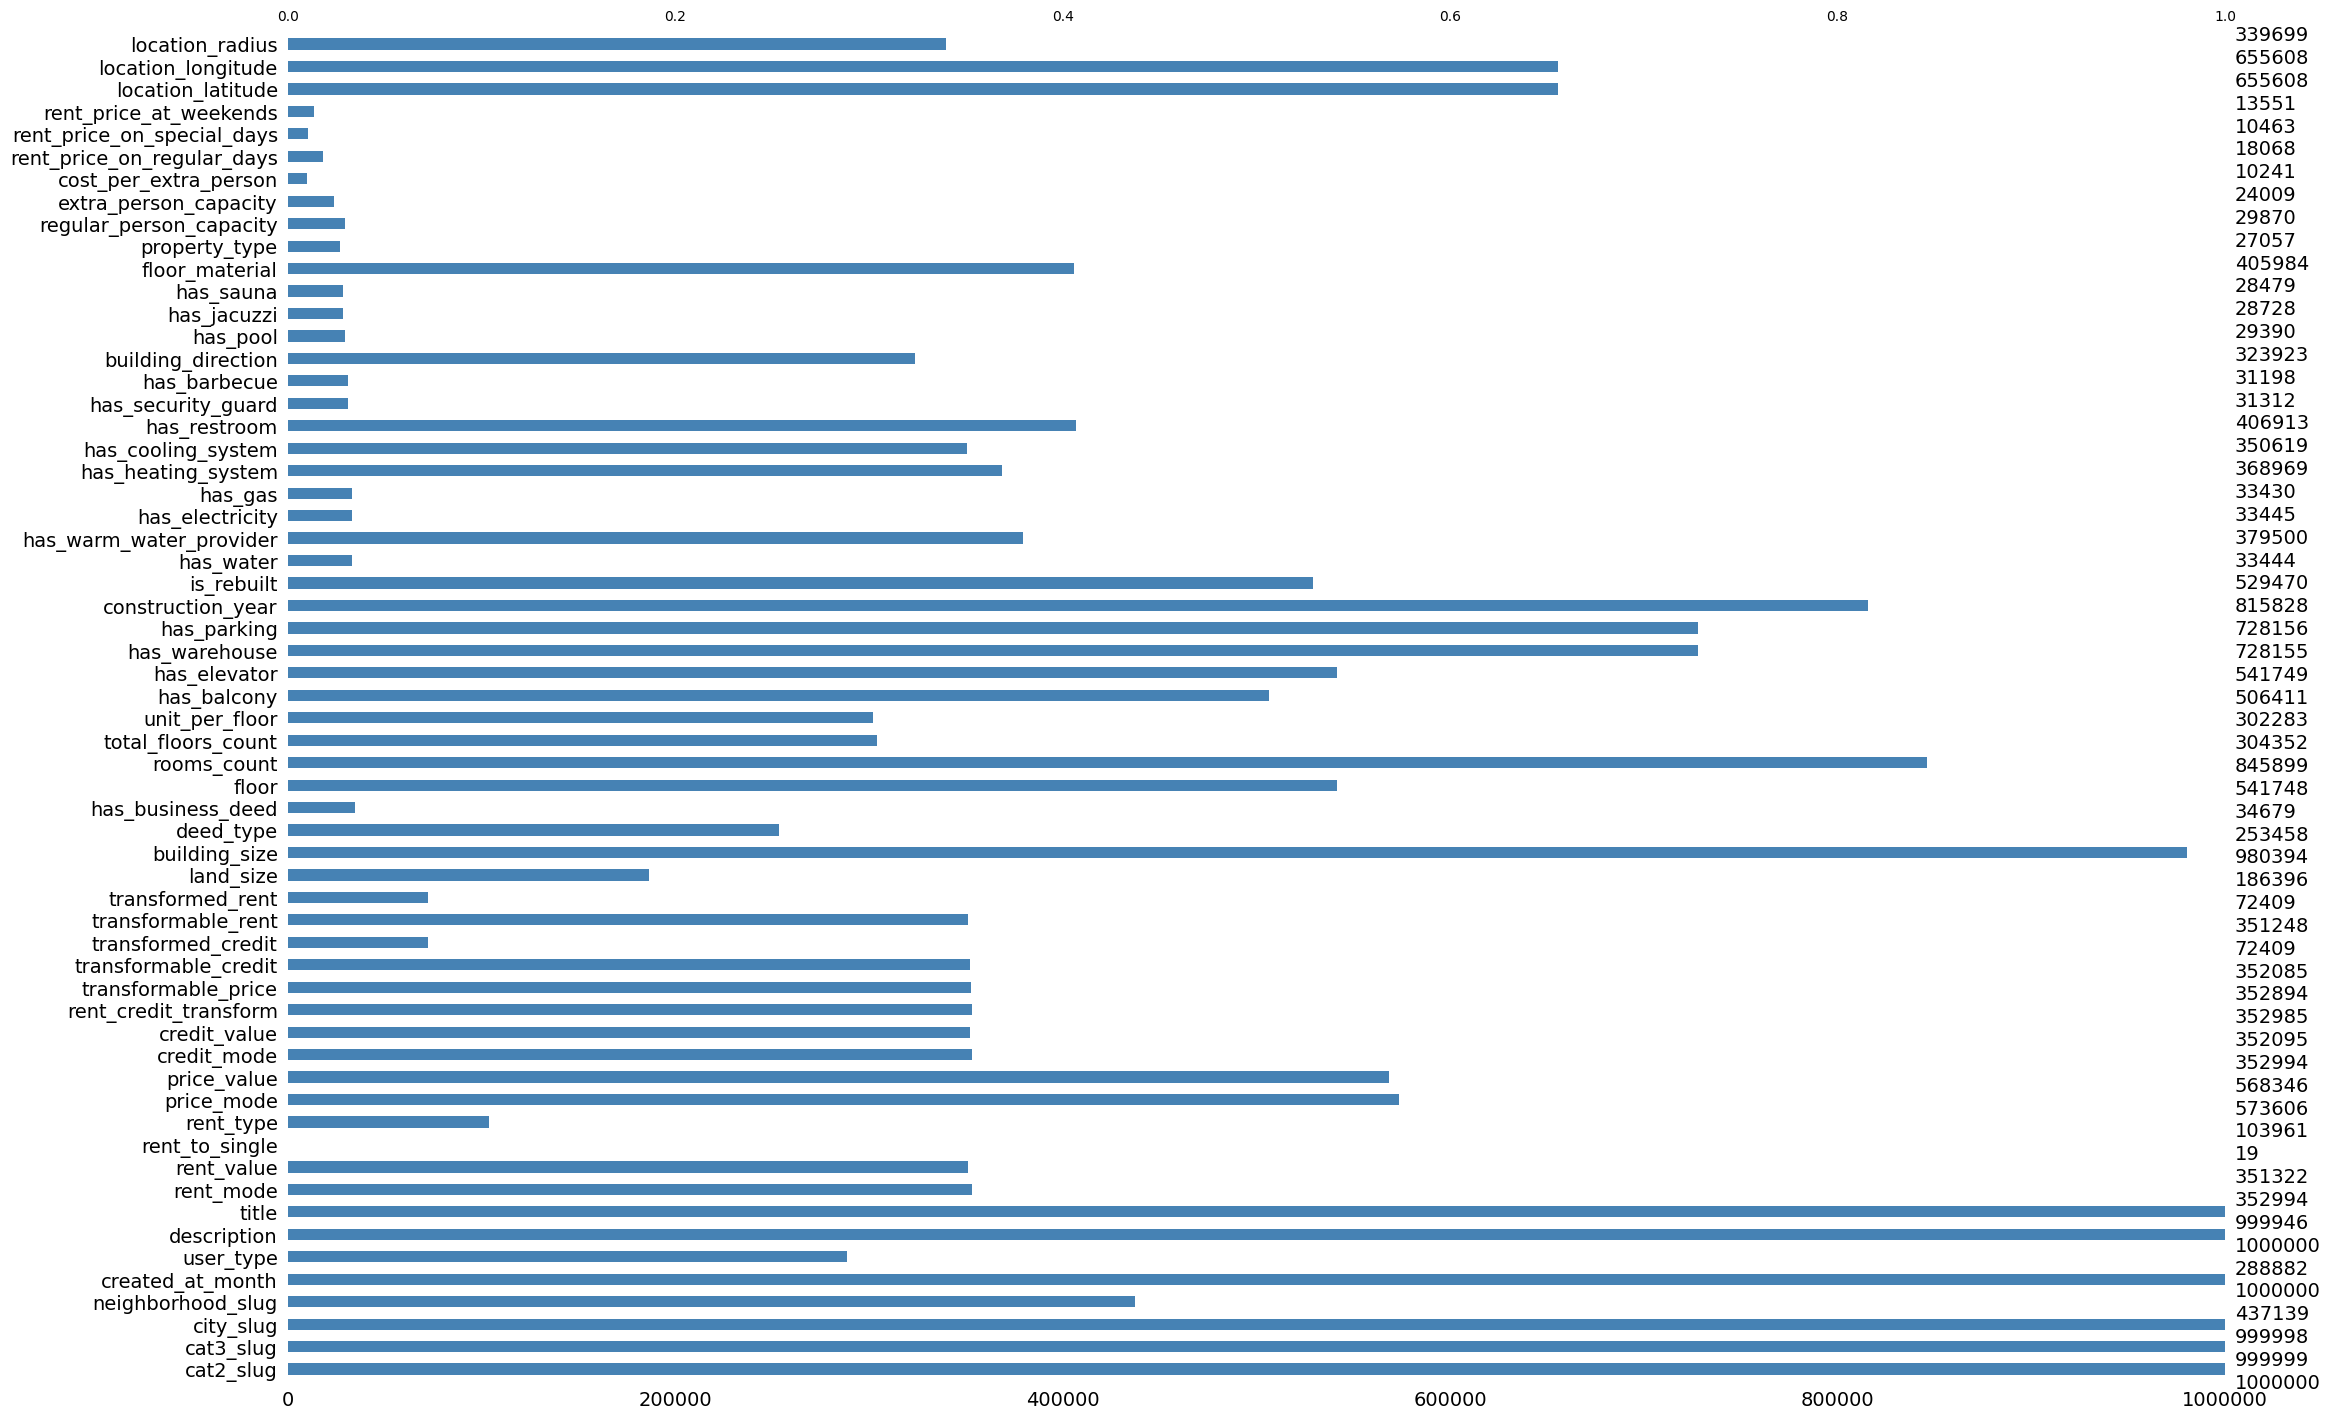

In [5]:
plt.figure(figsize=(18, 16))
msno.bar(data, fontsize=14, color='steelblue')

In [6]:
data['cat2_slug'].isnull().sum()

np.int64(0)

      nominal_mean     real_mean
1400  1.066667e+09  1.066667e+09
1401  1.882049e+10  1.289074e+10
1402  7.918916e+09  3.846748e+09
1403  1.743388e+10  6.391550e+09


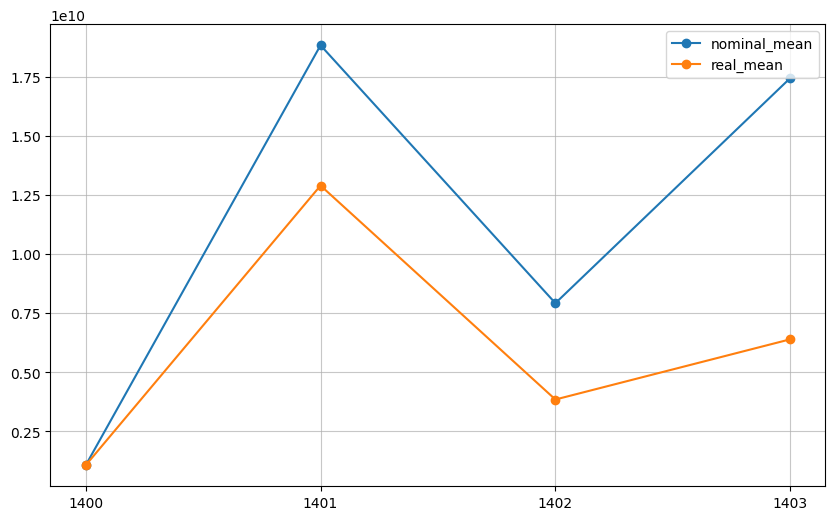

In [7]:
data['shamsi_year'] = data['created_at_month'].apply(extract_shamsi_year)
c = calculate_real_price(data, 'price_value', 'shamsi_year')
print(c)

c.plot.line(figsize=(10, 6), marker=('o'))
plt.grid(alpha=0.7)
plt.xticks([1400, 1401, 1402, 1403])
plt.show()

In [8]:
data['has_balcony'].unique()

array([nan, 'true', 'false', 'unselect', True, False], dtype=object)

In [9]:
data['has_pool'].value_counts()

has_pool
False    25669
True      3721
Name: count, dtype: int64

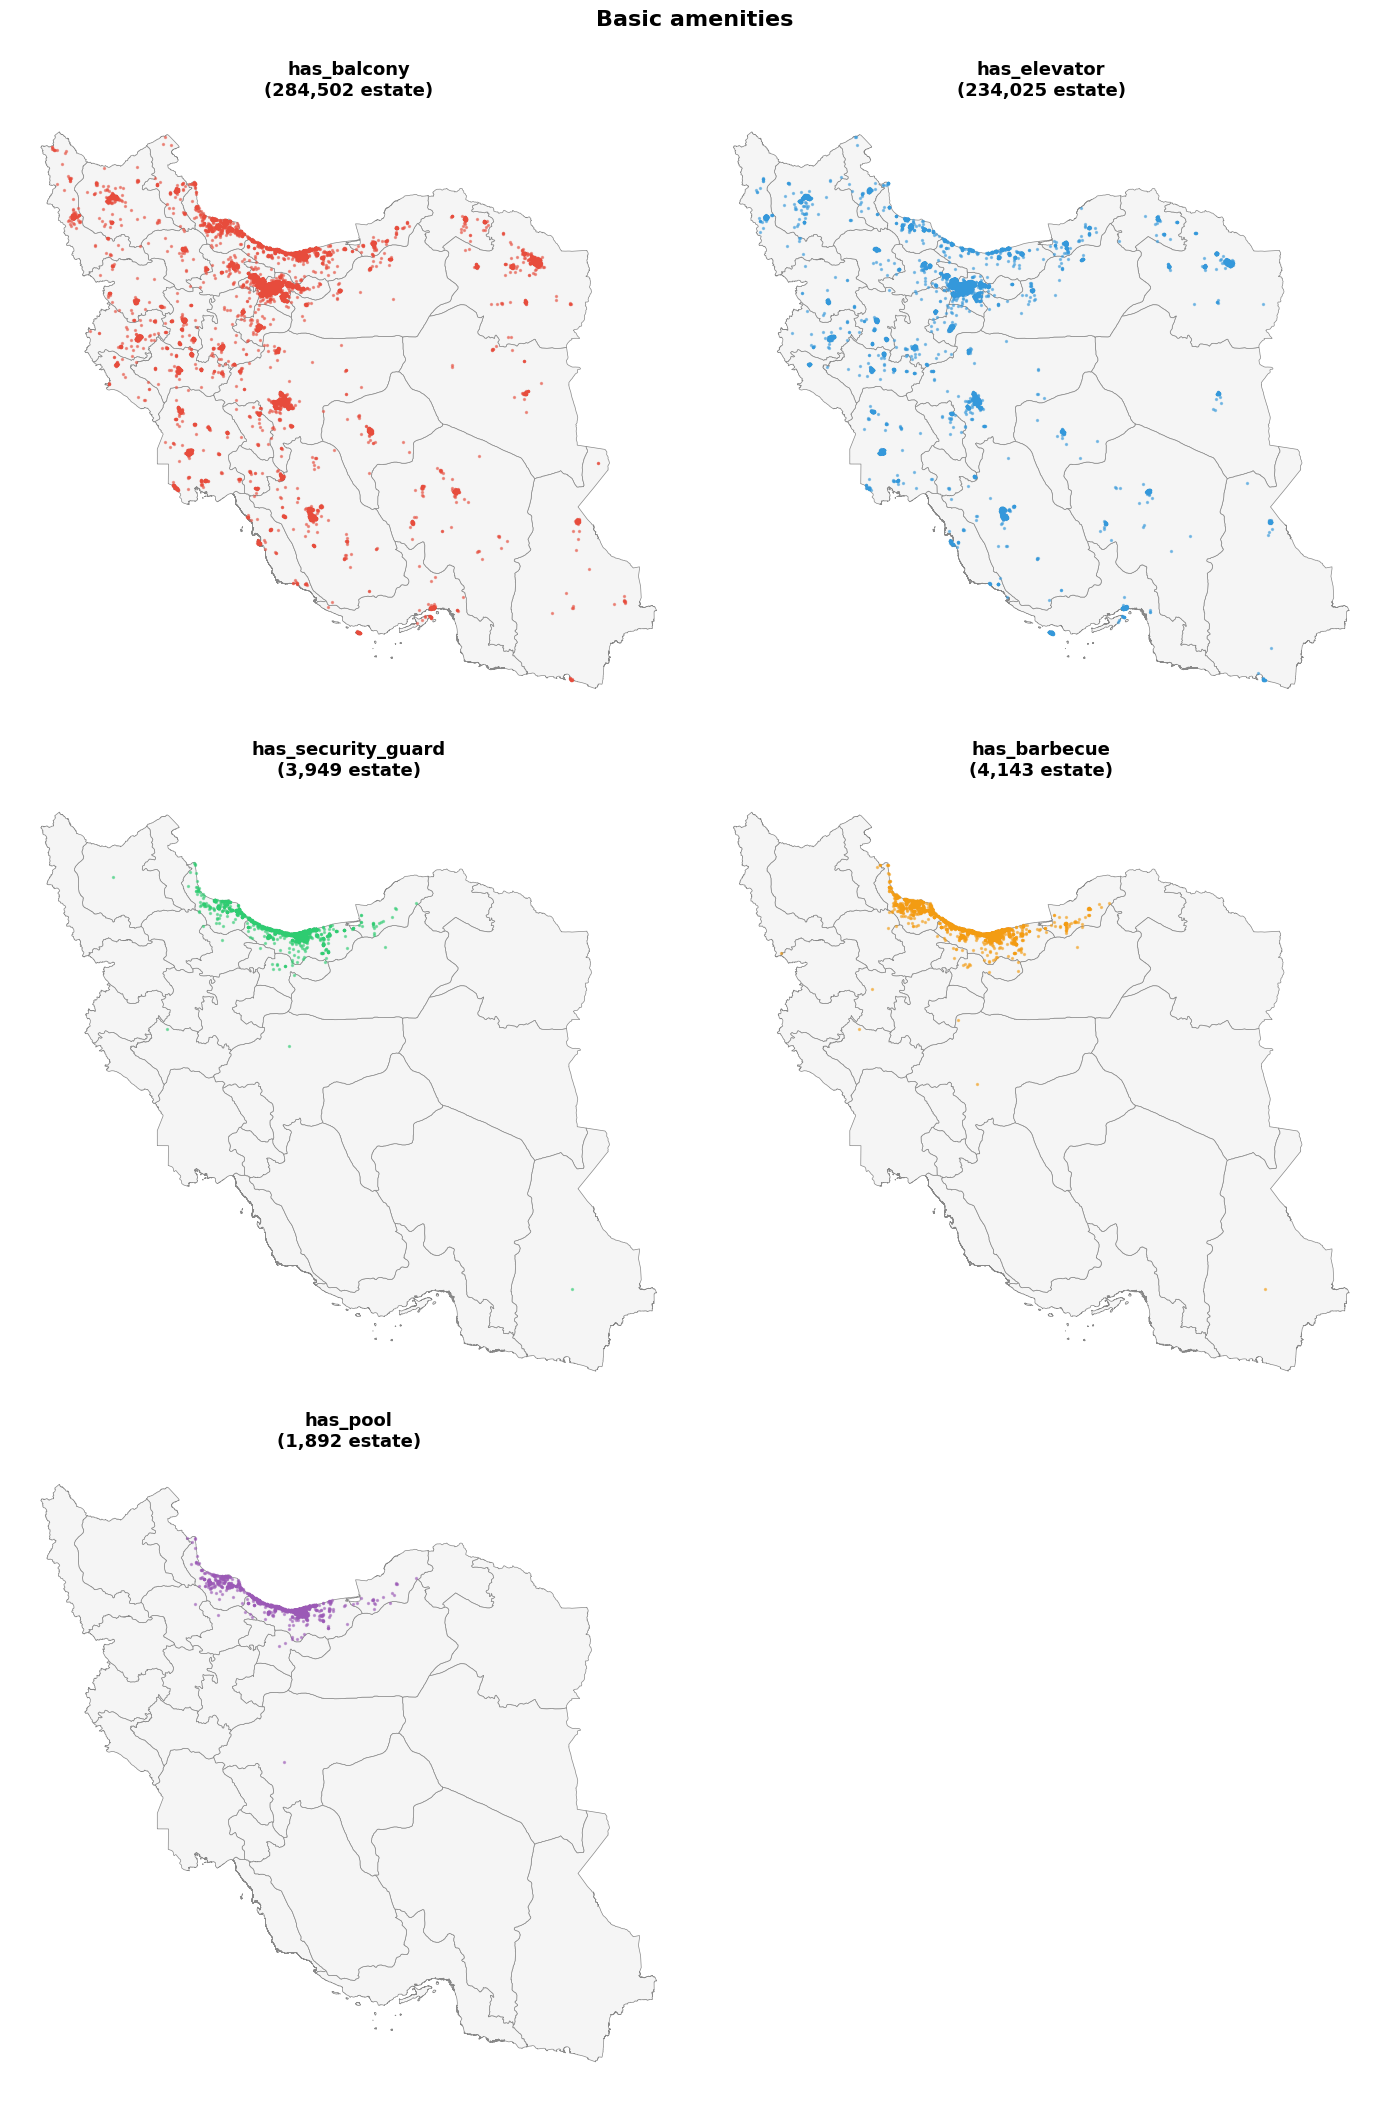

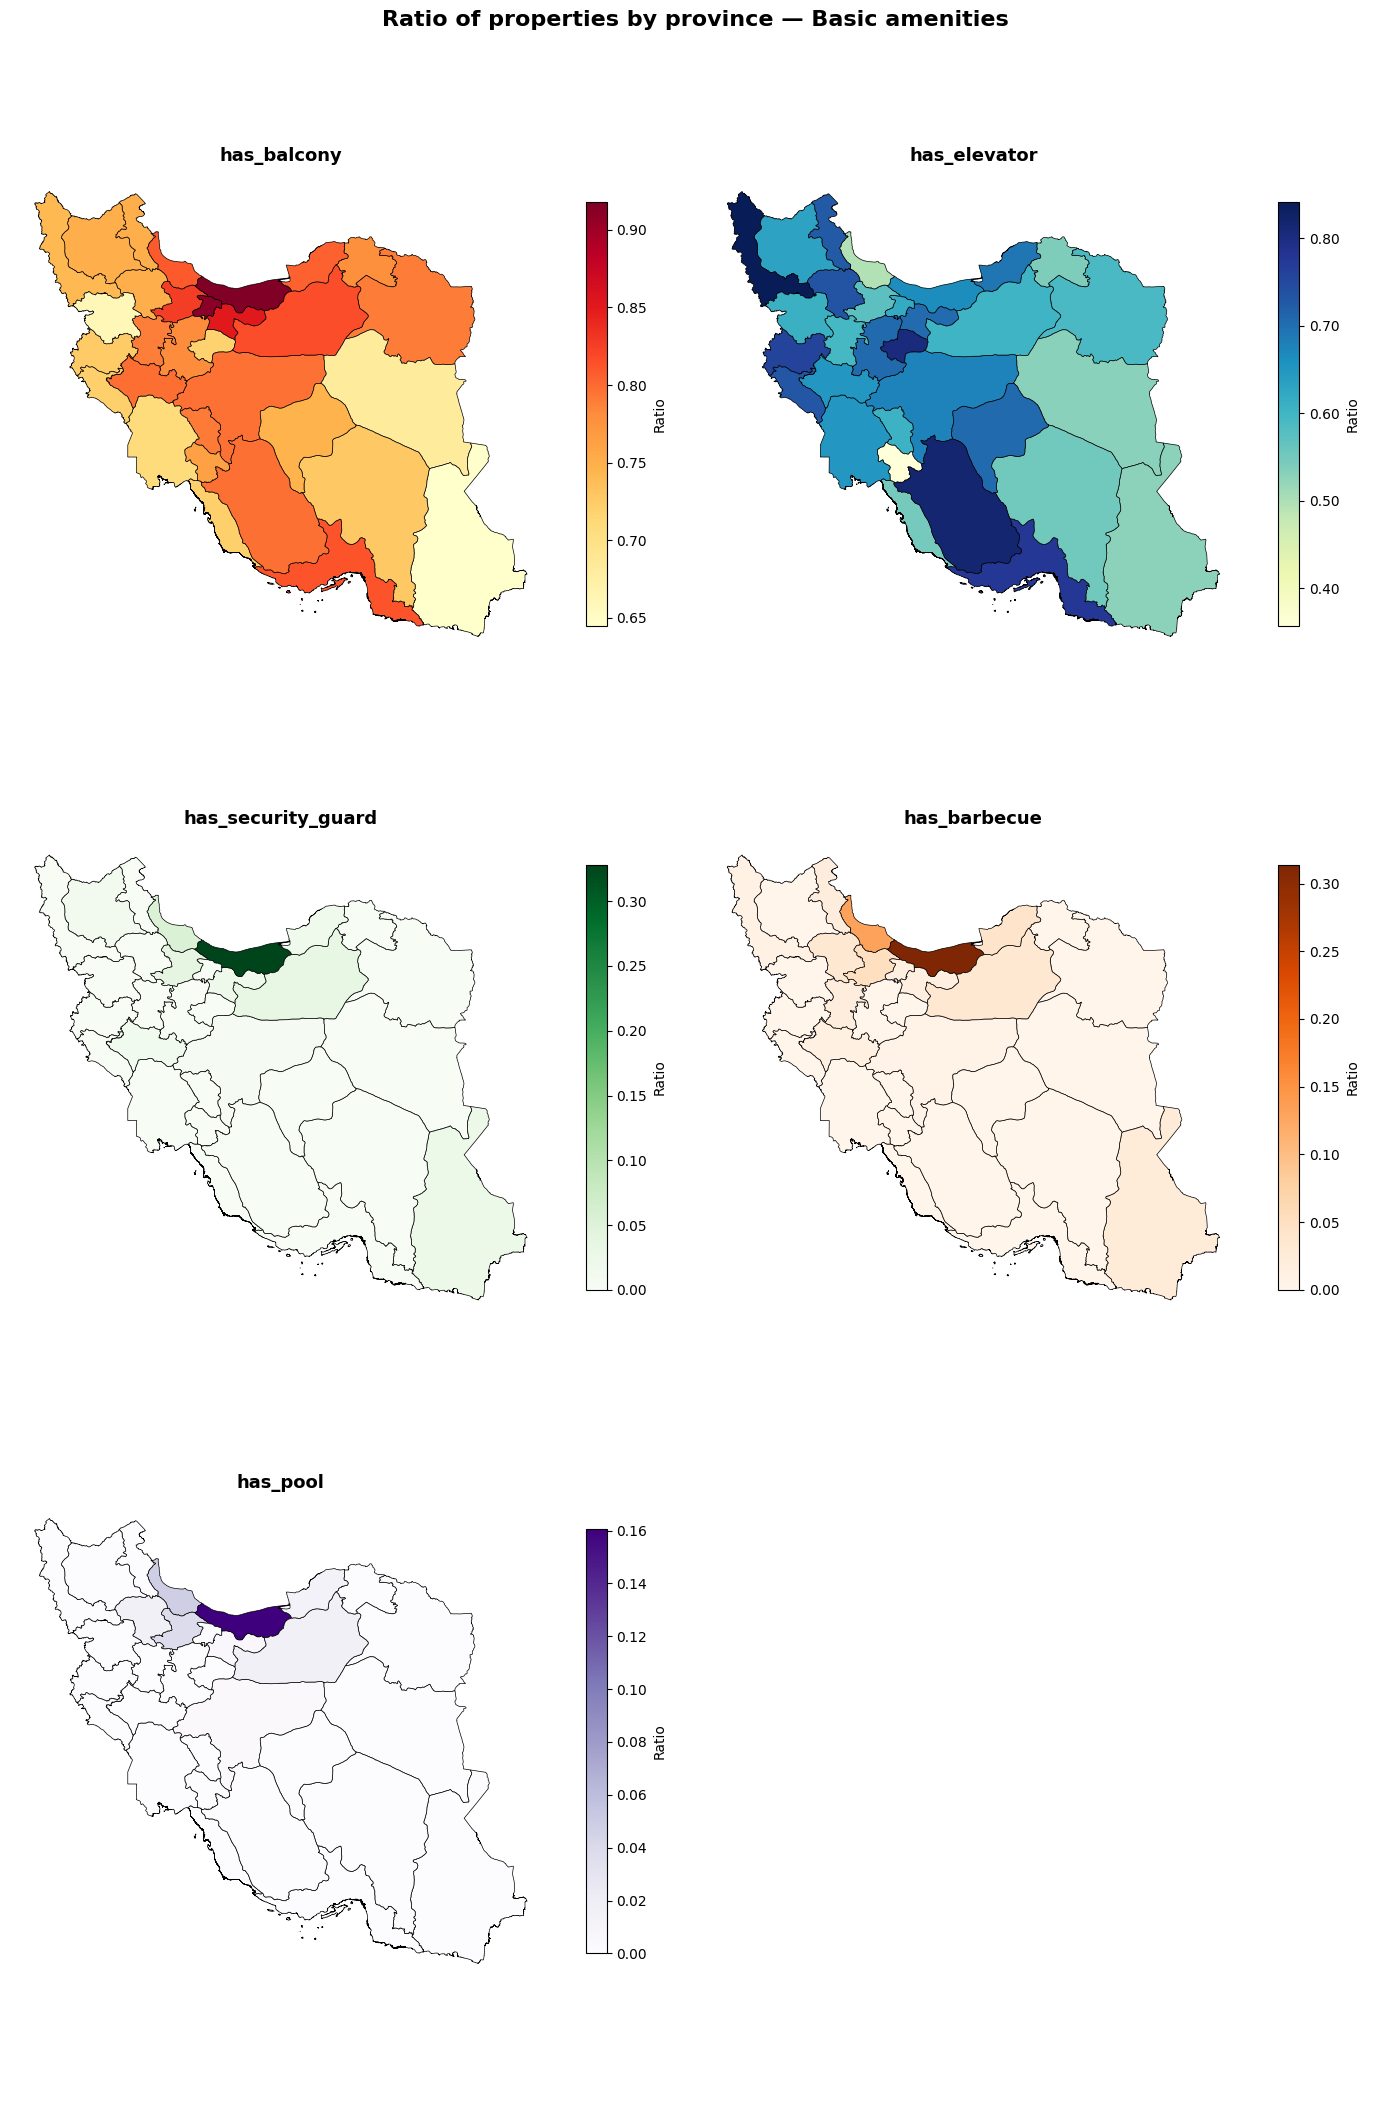

In [10]:
amenities = ['has_balcony', 'has_elevator', 'has_security_guard', 'has_barbecue', 'has_pool']

residential_cat = ['residential-sell', 'residential-rent']
# خوندن نقشه‌ی استان‌های ایران
iran_url = "https://raw.githubusercontent.com/ssepehrnoush/Iran-geojson-map-boundaries/master/ir_states_boundaries_coordinates.geojson"
iran = gpd.read_file(iran_url)

props_g1 = prepare_amenities_gdf(data=data, amenities=amenities,
                                 iran_map=iran, residential_cat=residential_cat)
plot_amenities_scatter(
    props_gdf=props_g1,
    iran_map=iran,
    amenities=amenities,
    group_title='Basic amenities',
    ncols=2,
)

plot_amenities_choropleth(
    props_gdf=props_g1,
    iran_map=iran,
    amenities=amenities,
    group_title='Basic amenities',
    min_listings=500,
    ncols=2,
)

In [11]:
result = test_business_deed_effect(data)
print(f"p-value: {result['test']['p_value']:.4e}")
print(f"Test: {result['test']['name']}")
print(f"Cohen's d: {result['effect_size']['cohens_d']:.4f}")
print(f"Interpretation: {result['effect_size']['label']}")
print(f"Significant: {result['conclusion']['is_significant']}")
print(f"Message: {result['conclusion']['message']}")

p-value: 3.0447e-60
Test: Mann-Whitney U
Cohen's d: 0.0018
Interpretation: negligible
Significant: True
Message: Business deed has a significant effect on price.


In [12]:
luxury_amenities = ['has_pool', 'has_barbecue', 'has_sauna', 'has_jacuzzi']
luxury_results = test_amenity_effect_on_price(data, luxury_amenities)
print(luxury_results.to_string(index=False))

     amenity  n_with  n_without    mean_with  mean_without  median_with  median_without      p_value  significant  cohens_d effect_size
 has_jacuzzi    1551      18132 2.488289e+10  1.470972e+10 3950000000.0    2700000000.0 1.291071e-53         True  0.013615  negligible
    has_pool    2587      17648 8.991334e+09  1.612405e+10 3500000000.0    2700000000.0 2.707733e-51         True -0.009679  negligible
   has_sauna    1013      18484 3.143974e+10  1.472905e+10 3100000000.0    2750000000.0 2.891680e-18         True  0.022258  negligible
has_barbecue    5617      16225 8.552569e+09  1.635443e+10 2850000000.0    2700000000.0 1.146216e-10         True -0.010999  negligible


In [13]:
non_luxury_amenities = ['has_balcony', 'has_elevator', 'has_parking', 'has_warehouse','has_water', 'has_electricity', 'has_gas']
non_luxury_results = test_amenity_effect_on_price(data, non_luxury_amenities)
print(non_luxury_results.to_string(index=False))

        amenity  n_with  n_without    mean_with  mean_without  median_with  median_without      p_value  significant  cohens_d effect_size
    has_balcony  266693      49530 1.731977e+10  8.957660e+09 3400000000.0    2100000000.0 0.000000e+00         True  0.014742  negligible
   has_elevator  220117      83258 1.894329e+10  6.383133e+09 4100000000.0    2100000000.0 0.000000e+00         True  0.025231  negligible
    has_parking  348755      76360 1.681250e+10  9.312416e+09 3600000000.0    1780000000.0 0.000000e+00         True  0.014198  negligible
  has_warehouse  362440      62675 1.669922e+10  8.329862e+09 3390000000.0    2050000000.0 0.000000e+00         True  0.015844  negligible
has_electricity   11289      12435 1.723774e+10  1.009471e+10 2800000000.0    2550000000.0 1.053697e-11         True  0.010495  negligible
        has_gas   11193      12528 1.734519e+10  1.004921e+10 2800000000.0    2565000000.0 1.697867e-11         True  0.010719  negligible
      has_water   11352    